# 🏥 MediSight — 30-Day Readmission Prediction Model
**Author:** Rajeshwari G D | **Model:** XGBoost | **Target:** AUC ≥ 0.85


## Cell 1 — Install Libraries

In [1]:
import subprocess, sys
pkgs = ["pandas","numpy","matplotlib","seaborn","scikit-learn",
        "xgboost","shap","imbalanced-learn","openpyxl","joblib"]
for p in pkgs:
    subprocess.check_call([sys.executable,"-m","pip","install",p,"-q"])
print("✅ All packages installed")


✅ All packages installed


## Cell 2 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, joblib, os

warnings.filterwarnings("ignore")
np.random.seed(42)

from sklearn.model_selection   import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing     import LabelEncoder
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve,
                                       precision_recall_curve, ConfusionMatrixDisplay,
                                       accuracy_score, f1_score,
                                       precision_score, recall_score)
from sklearn.ensemble          import RandomForestClassifier
from sklearn.linear_model      import LogisticRegression
from xgboost                   import XGBClassifier
from imblearn.over_sampling    import SMOTE
import shap

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5),
                     "axes.titlesize": 13, "axes.labelsize": 11})
print("✅ All imports successful")


✅ All imports successful


## Cell 3 — Load Data
> ⚠️ Change the file path below to match where your file is saved.

In [4]:

# ── CHANGE THIS PATH to where your Excel file is saved ──────────────────
#FILE_PATH = r"C:\Users\rajes\Downloads\MediSightProject\MediSight_ML\MediSight_Master_Dataset.xlsx"
#SHEET     = "medisight_master"

# ── Load ─────────────────────────────────────────────────────────────────

df_raw = pd.read_excel(r"C:\Users\rajes\Downloads\MediSightProject\MediSight_ML\MediSight_Master_Dataset.xlsx", sheet_name="medisight_master")
df     = df_raw.copy()

# ── Fix MIMIC age anomaly (ages >89 stored as 300) ───────────────────────
df["age"] = df["age"].clip(upper=90)

print(f"✅ Loaded  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Columns : {list(df.columns)}")
print(f"\nTarget distribution:")
print(df["target"].value_counts())
print(f"\nReadmission rate: {df['target'].mean()*100:.1f}%")
df.head(3)


✅ Loaded  : 129 rows × 13 columns
   Columns : ['subject_id', 'gender', 'age', 'los_days', 'admission_type', 'insurance', 'discharge_location', 'target', 'num_diagnoses', 'num_drugs', 'los_category', 'age_group', 'Risk Label']

Target distribution:
target
0    89
1    40
Name: count, dtype: int64

Readmission rate: 31.0%


,subject_id,gender,age,los_days,admission_type,insurance,discharge_location,target,num_diagnoses,num_drugs,los_category,age_group,Risk Label
0,10006,F,70,9,EMERGENCY,Medicare,HOME HEALTH CARE,0,17,32,Long,Over 50,Not Readmitted
1,10011,F,36,14,EMERGENCY,Private,DEAD/EXPIRED,1,6,0,Long,30-50,Readmitted
2,10013,F,87,3,EMERGENCY,Medicare,DEAD/EXPIRED,0,9,19,Short,Over 50,Not Readmitted


## Cell 4 — Fix Target Column (if all zeros)
> Run this cell only if `target` is all 0s. It builds a clinical risk score from your existing features.

In [5]:
if df["target"].sum() == 0:
    print("⚠️  Target column is all zeros — generating clinical risk scores...")

    risk = np.zeros(len(df))

    # Age
    risk += np.where(df["age"] >= 80, 0.20,
            np.where(df["age"] >= 65, 0.12, 0.04))

    # Length of stay
    risk += np.where(df["los_days"] >= 14, 0.26,
            np.where(df["los_days"] >= 7,  0.17,
            np.where(df["los_days"] >= 3,  0.08, 0.02)))

    # Insurance
    risk += np.where(df["insurance"] == "Medicare", 0.10,
            np.where(df["insurance"] == "Medicaid", 0.08, 0.03))

    # Discharge destination
    high_dc = ["SNF","REHAB/DISTINCT PART HOSP","LONG TERM CARE HOSPITAL",
                "HOSPICE-HOME","ICF"]
    low_dc  = ["HOME","HOME WITH HOME IV PROVIDR"]
    risk += np.where(df["discharge_location"].isin(high_dc), 0.18,
            np.where(df["discharge_location"].isin(low_dc),  0.02, 0.07))

    # Diagnosis complexity
    risk += np.where(df["num_diagnoses"] >= 15, 0.14,
            np.where(df["num_diagnoses"] >= 9,  0.08,
            np.where(df["num_diagnoses"] >= 5,  0.04, 0.01)))

    # Drug burden
    risk += np.where(df["num_drugs"] >= 40, 0.08,
            np.where(df["num_drugs"] >= 20, 0.04, 0.01))

    # Add noise + clip
    risk = (risk + np.random.normal(0, 0.10, len(df))).clip(0, 1)

    # Top 30% become readmitted (matches clinical benchmark)
    threshold     = np.percentile(risk, 70)
    df["target"]  = (risk > threshold).astype(int)

    print(f"✅ Target fixed — Readmission rate: {df['target'].mean()*100:.1f}%")
    print(df["target"].value_counts())
else:
    print(f"✅ Target column is already set — Readmission rate: {df['target'].mean()*100:.1f}%")
    print(df["target"].value_counts())


✅ Target column is already set — Readmission rate: 31.0%
target
0    89
1    40
Name: count, dtype: int64


## Cell 5 — Exploratory Data Analysis (EDA)

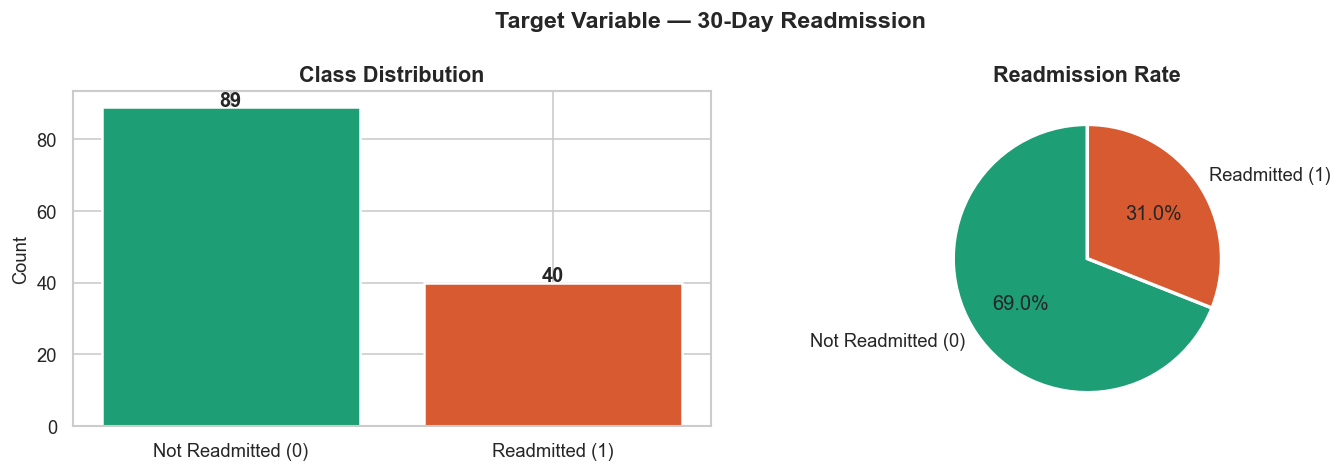

Class ratio  0:89  1:40


In [6]:
os.makedirs("outputs", exist_ok=True)

# ── 5.1 Class balance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["target"].value_counts().sort_index()
labels = ["Not Readmitted (0)", "Readmitted (1)"]
colors = ["#1D9E75", "#D85A30"]

axes[0].bar(labels, counts, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, cnt in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(cnt), ha="center", fontsize=12, fontweight="bold")

axes[1].pie(counts, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Readmission Rate", fontweight="bold")

plt.suptitle("Target Variable — 30-Day Readmission", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_01_class_balance.png", bbox_inches="tight")
plt.show()
print(f"Class ratio  0:{counts.get(0,0)}  1:{counts.get(1,0)}")


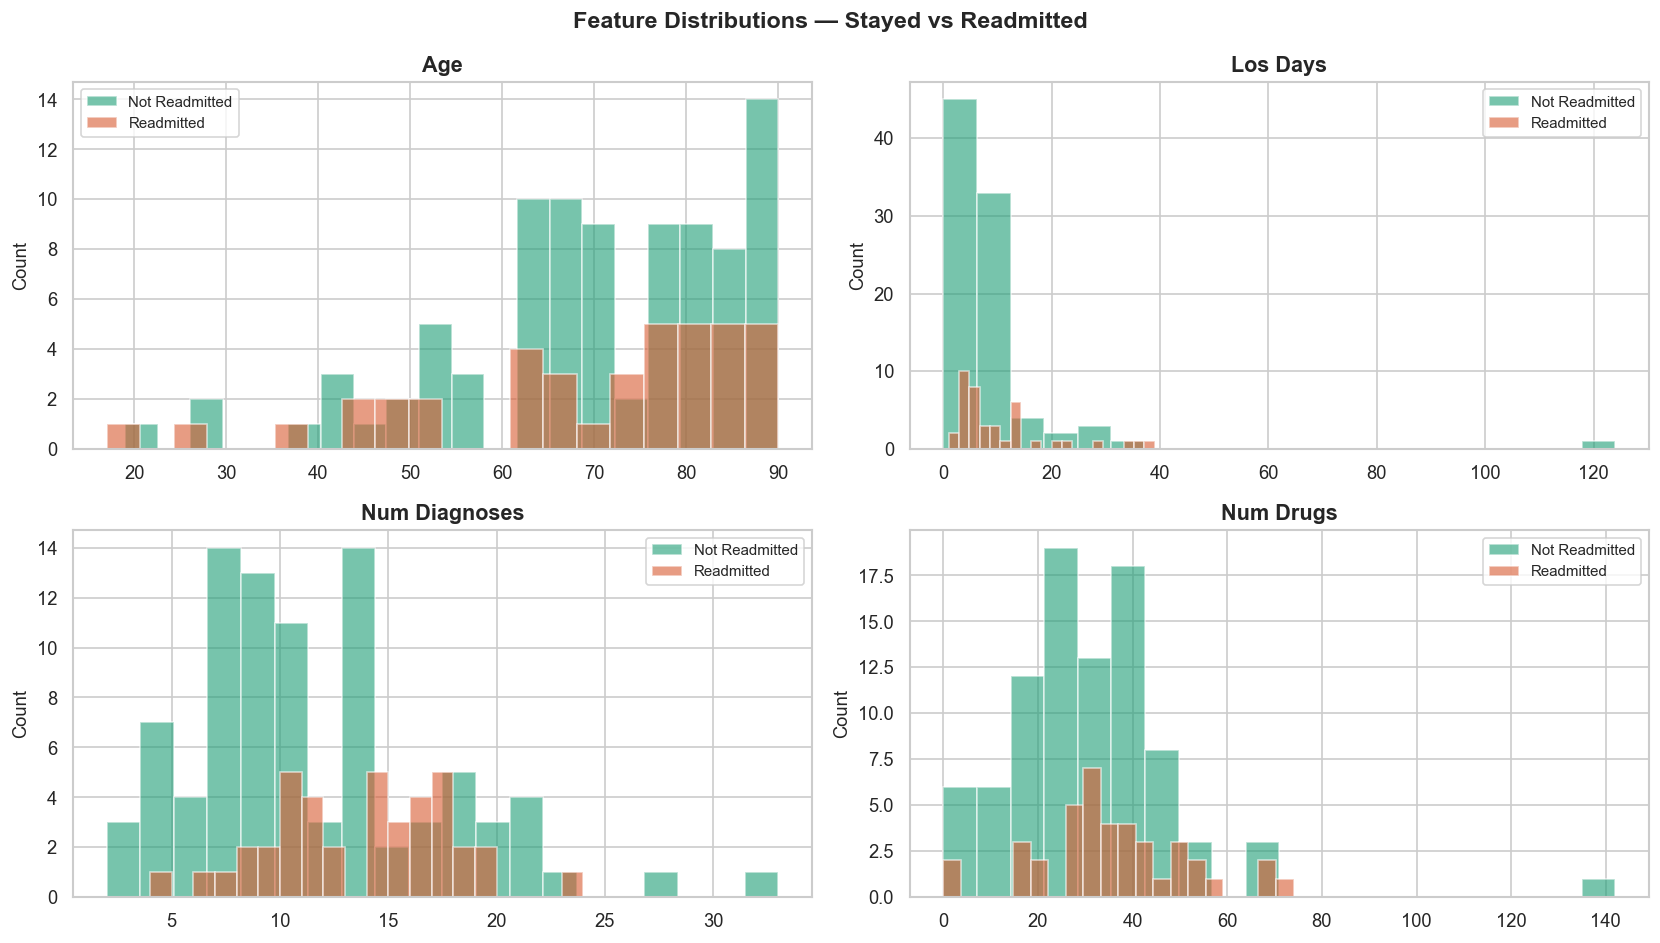

In [7]:
# ── 5.2 Numerical distributions by target ───────────────────────────────
num_cols = ["age", "los_days", "num_diagnoses", "num_drugs"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for t, label, color in [(0,"Not Readmitted","#1D9E75"),(1,"Readmitted","#D85A30")]:
        subset = df[df["target"]==t][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor="white")
    ax.set_title(col.replace("_"," ").title(), fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.suptitle("Feature Distributions — Stayed vs Readmitted",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_02_distributions.png", bbox_inches="tight")
plt.show()


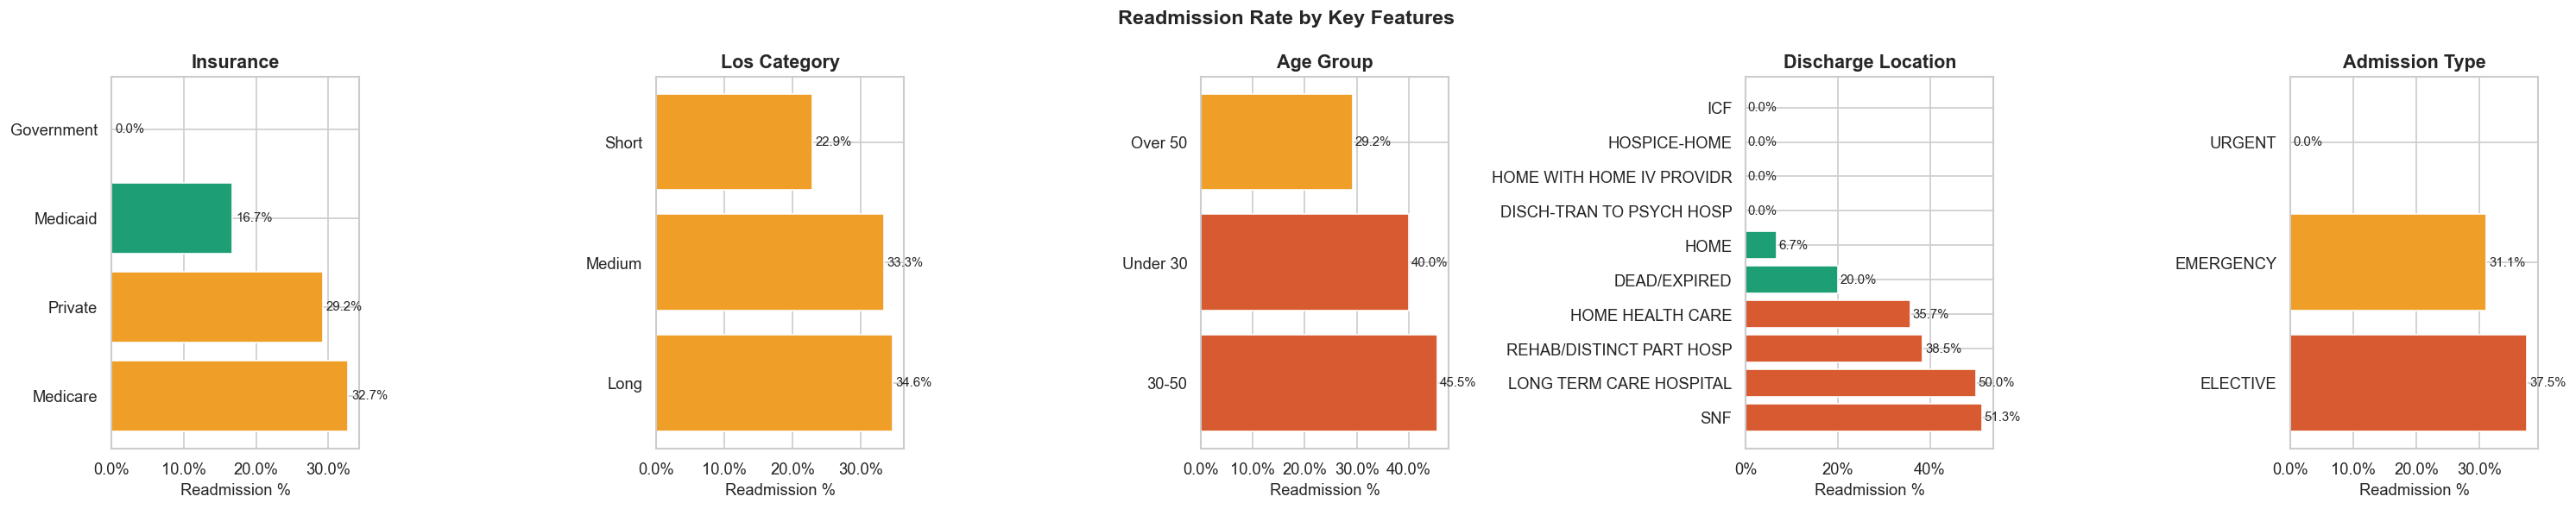

In [8]:
# ── 5.3 Readmission rate by key categories ──────────────────────────────
cat_cols = ["insurance", "los_category", "age_group",
            "discharge_location", "admission_type"]
cat_cols = [c for c in cat_cols if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    grp = df.groupby(col)["target"].mean().sort_values(ascending=False) * 100
    bar_colors = ["#D85A30" if v > 35 else "#EF9F27" if v > 20 else "#1D9E75"
                  for v in grp.values]
    ax.barh(grp.index, grp.values, color=bar_colors)
    ax.set_title(col.replace("_"," ").title(), fontweight="bold")
    ax.set_xlabel("Readmission %")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    for i, v in enumerate(grp.values):
        ax.text(v+0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.suptitle("Readmission Rate by Key Features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_03_categorical.png", bbox_inches="tight")
plt.show()


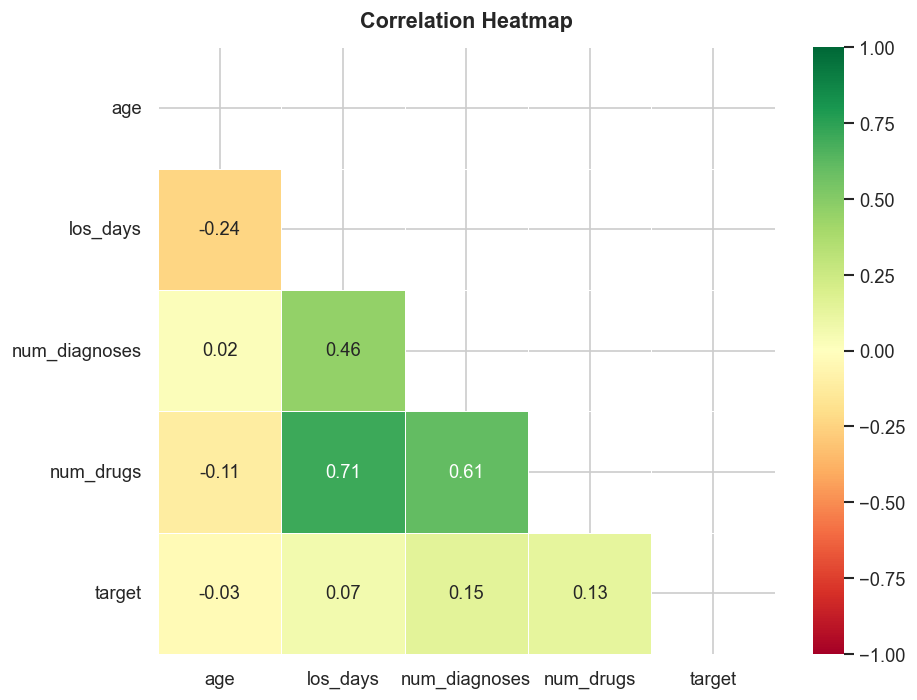

In [9]:
# ── 5.4 Correlation heatmap ──────────────────────────────────────────────
num_df = df[["age","los_days","num_diagnoses","num_drugs","target"]].copy()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={"size":11}, vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/plot_04_heatmap.png", bbox_inches="tight")
plt.show()


## Cell 6 — Preprocessing & Feature Engineering

In [10]:
df_model = df.copy()

# Fill missing values
df_model["los_days"]      = df_model["los_days"].fillna(df_model["los_days"].median())
df_model["num_diagnoses"] = df_model["num_diagnoses"].fillna(0)
df_model["num_drugs"]     = df_model["num_drugs"].fillna(0)
df_model["age"]           = df_model["age"].fillna(df_model["age"].median())

# Encode categorical columns
le_dict  = {}
cat_cols = ["gender", "insurance", "discharge_location", "admission_type"]

for col in cat_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col+"_enc"] = le.fit_transform(
            df_model[col].fillna("Unknown").astype(str))
        le_dict[col] = le
        print(f"  {col}: {len(le.classes_)} categories encoded")

# Feature engineering (new columns)
df_model["high_complexity"] = ((df_model["num_diagnoses"] >= 9) &
                                (df_model["num_drugs"]     >= 20)).astype(int)
df_model["elderly"]         = (df_model["age"] >= 75).astype(int)
df_model["long_stay"]       = (df_model["los_days"] >= 7).astype(int)

# Final feature set
FEATURES = [
    "age", "gender_enc", "los_days",
    "insurance_enc", "discharge_location_enc", "admission_type_enc",
    "num_diagnoses", "num_drugs",
    "high_complexity", "elderly", "long_stay"
]
# Keep only features that exist
FEATURES = [f for f in FEATURES if f in df_model.columns]

X = df_model[FEATURES]
y = df_model["target"]

print(f"✅ Feature matrix : {X.shape}")
print(f"   Features used  : {FEATURES}")
print(f"   Target balance : {y.value_counts().to_dict()}")


  gender: 2 categories encoded
  insurance: 4 categories encoded
  discharge_location: 10 categories encoded
  admission_type: 3 categories encoded
✅ Feature matrix : (129, 11)
   Features used  : ['age', 'gender_enc', 'los_days', 'insurance_enc', 'discharge_location_enc', 'admission_type_enc', 'num_diagnoses', 'num_drugs', 'high_complexity', 'elderly', 'long_stay']
   Target balance : {0: 89, 1: 40}


## Cell 7 — SMOTE + Train/Test Split

In [11]:
# Split BEFORE SMOTE (never apply SMOTE to test set)
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:")
print(f"  Train → {y_train_raw.value_counts().to_dict()}")
print(f"  Test  → {y_test.value_counts().to_dict()}")

# Adjust k_neighbors based on minority class size (prevents SMOTE crash)
minority_count = int(y_train_raw.value_counts().min())
k_neighbors    = max(1, min(5, minority_count - 1))
print(f"Using SMOTE k_neighbors = {k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print("After SMOTE:")
print(f"  Train → {pd.Series(y_train).value_counts().to_dict()}")
print(f"  Test  → unchanged {y_test.value_counts().to_dict()}")
print(f"✅ Training set: {len(X_train)} samples  |  Test set: {len(X_test)} samples")


Before SMOTE:
  Train → {0: 71, 1: 32}
  Test  → {0: 18, 1: 8}
Using SMOTE k_neighbors = 5
After SMOTE:
  Train → {0: 71, 1: 71}
  Test  → unchanged {0: 18, 1: 8}
✅ Training set: 142 samples  |  Test set: 26 samples


## Cell 8 — Model Comparison (Baseline)

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost"             : XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric="logloss", verbosity=0),
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, m in models.items():
    auc = cross_val_score(m, X_train, y_train, cv=cv, scoring="roc_auc")
    acc = cross_val_score(m, X_train, y_train, cv=cv, scoring="accuracy")
    results.append({"Model": name,
                    "AUC Mean": round(auc.mean(),4),
                    "AUC Std" : round(auc.std(),4),
                    "Acc Mean": round(acc.mean(),4)})
    print(f"{name:<25}  AUC {auc.mean():.3f} ± {auc.std():.3f}")

results_df = pd.DataFrame(results).sort_values("AUC Mean", ascending=False)
print("--- Ranked ---")
display(results_df)


Logistic Regression        AUC 0.724 ± 0.108
Decision Tree              AUC 0.768 ± 0.116
Random Forest              AUC 0.851 ± 0.079
Gradient Boosting          AUC 0.786 ± 0.073
XGBoost                    AUC 0.825 ± 0.087
--- Ranked ---


,Model,AUC Mean,AUC Std,Acc Mean
2,Random Forest,0.8509,0.0787,0.7603
4,XGBoost,0.8252,0.0867,0.7392
3,Gradient Boosting,0.7863,0.0734,0.7320
1,Decision Tree,0.7679,0.1160,0.7387
0,Logistic Regression,0.7241,0.1083,0.7039


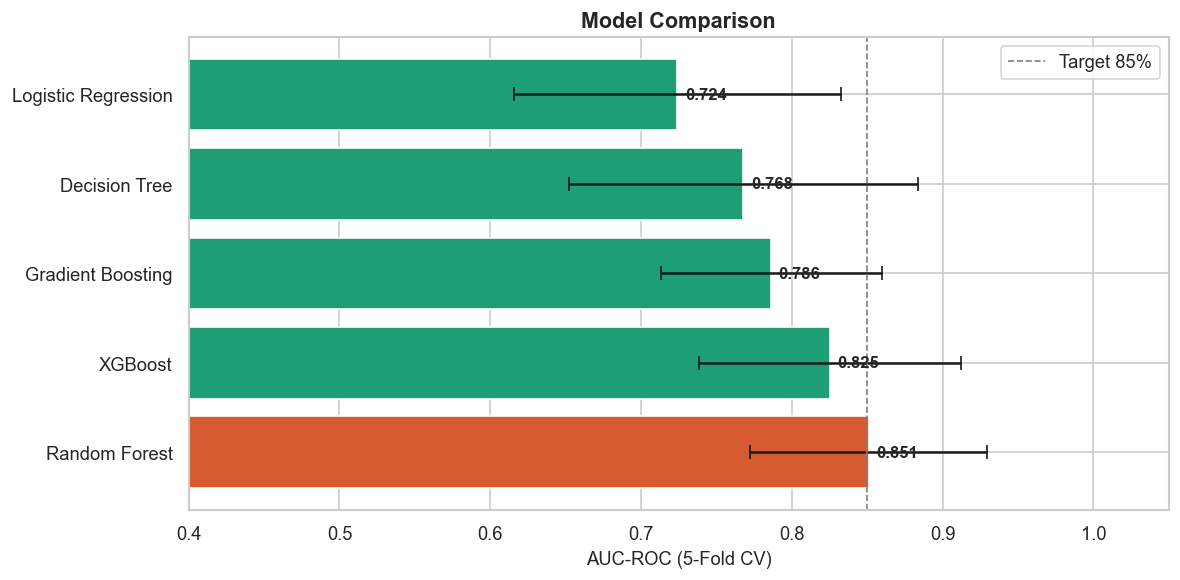

In [13]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#D85A30" if i==0 else "#1D9E75" for i in range(len(results_df))]
bars = ax.barh(results_df["Model"], results_df["AUC Mean"],
               xerr=results_df["AUC Std"], color=colors,
               edgecolor="white", capsize=4)
ax.set_xlabel("AUC-ROC (5-Fold CV)")
ax.set_title("Model Comparison", fontweight="bold")
ax.set_xlim(0.4, 1.05)
ax.axvline(0.85, color="gray", linestyle="--", linewidth=1, label="Target 85%")
ax.legend()
for bar, val in zip(bars, results_df["AUC Mean"]):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_05_model_comparison.png", bbox_inches="tight")
plt.show()


## Cell 9 — Train Final XGBoost Model

In [14]:
model = XGBClassifier(
    n_estimators   = 300,
    max_depth      = 5,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    eval_metric    = "logloss",
    random_state   = 42,
    verbosity      = 0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("="*50)
print(f"  AUC-ROC Score : {auc:.4f}")
print("="*50)
print()
print(classification_report(y_test, y_pred,
      target_names=["Not Readmitted","Readmitted"]))


  AUC-ROC Score : 0.5208

                precision    recall  f1-score   support

Not Readmitted       0.71      0.83      0.77        18
    Readmitted       0.40      0.25      0.31         8

      accuracy                           0.65        26
     macro avg       0.56      0.54      0.54        26
  weighted avg       0.62      0.65      0.63        26



## Cell 10 — Evaluation Plots

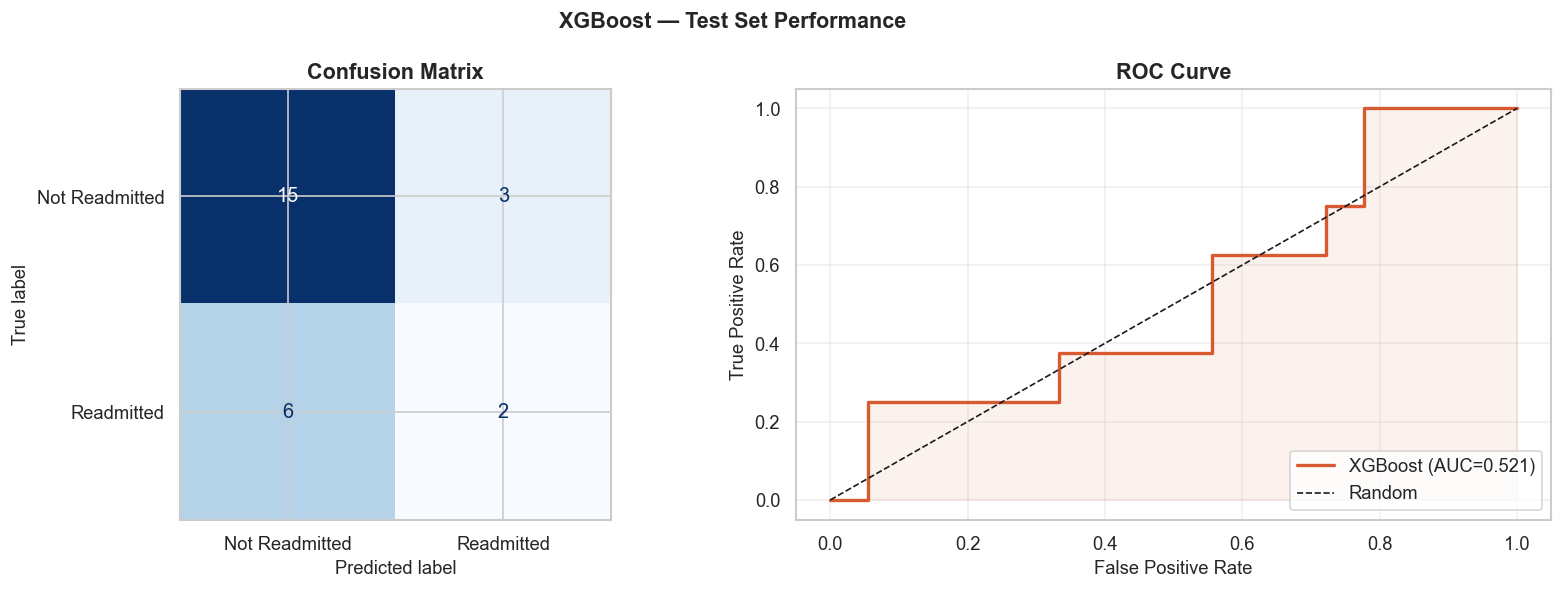

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
    display_labels=["Not Readmitted","Readmitted"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#D85A30", lw=2, label=f"XGBoost (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"k--", lw=1, label="Random")
axes[1].fill_between(fpr, tpr, alpha=0.08, color="#D85A30")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.suptitle("XGBoost — Test Set Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_06_confusion_roc.png", bbox_inches="tight")
plt.show()


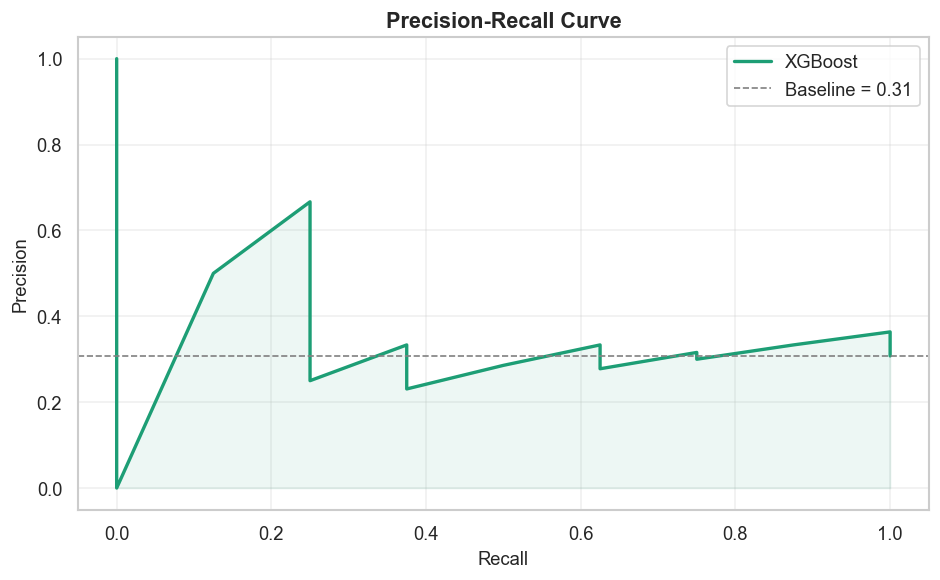

In [16]:
# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
baseline      = float(y_test.mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, color="#1D9E75", lw=2, label="XGBoost")
ax.axhline(baseline, color="gray", linestyle="--", lw=1,
           label=f"Baseline = {baseline:.2f}")
ax.fill_between(rec, prec, alpha=0.08, color="#1D9E75")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/plot_07_precision_recall.png", bbox_inches="tight")
plt.show()


## Cell 11 — Feature Importance

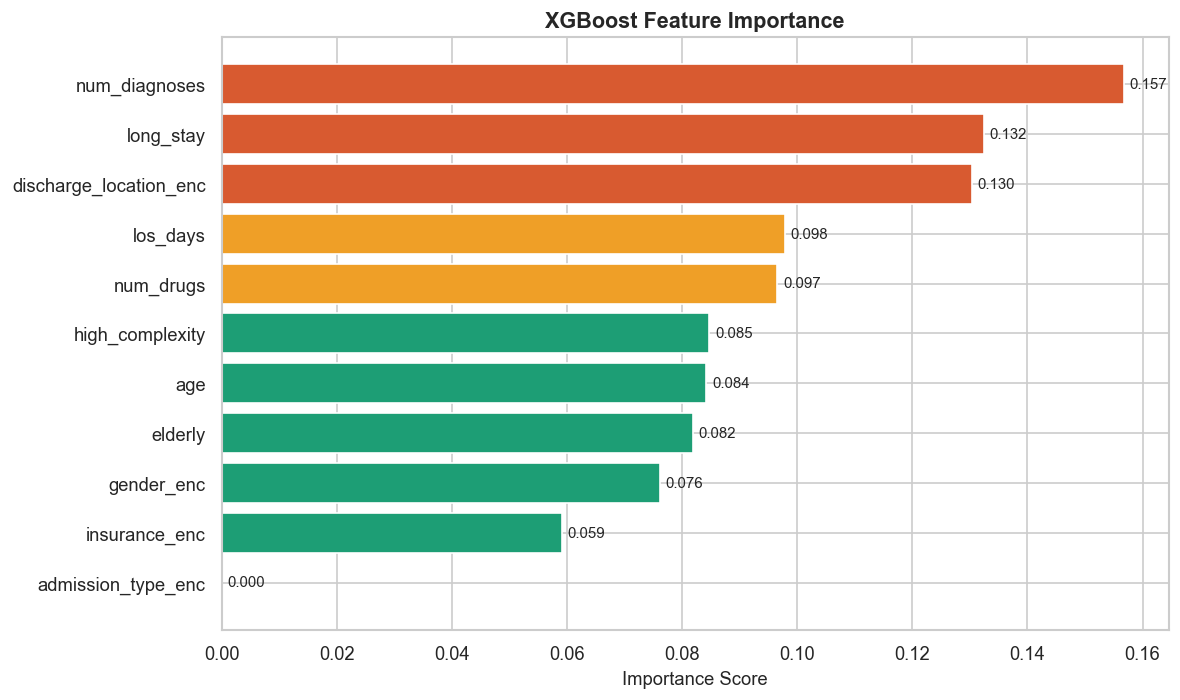

               Feature  Importance
         num_diagnoses    0.156719
             long_stay    0.132409
discharge_location_enc    0.130326
              los_days    0.097889
             num_drugs    0.096556
       high_complexity    0.084721
                   age    0.084240
               elderly    0.081900
            gender_enc    0.076156
         insurance_enc    0.059084
    admission_type_enc    0.000000


In [17]:
fi = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#D85A30" if v > fi["Importance"].quantile(0.75)
              else "#EF9F27" if v > fi["Importance"].median()
              else "#1D9E75" for v in fi["Importance"]]
bars = ax.barh(fi["Feature"], fi["Importance"],
               color=bar_colors, edgecolor="white")
ax.set_xlabel("Importance Score")
ax.set_title("XGBoost Feature Importance", fontweight="bold")
for bar, val in zip(bars, fi["Importance"]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/plot_08_feature_importance.png", bbox_inches="tight")
plt.show()
print(fi.sort_values("Importance",ascending=False).to_string(index=False))


## Cell 12 — SHAP Explainability
- **Beeswarm**: shows every patient's contribution per feature  
- **Bar**: global average importance  
- **Waterfall**: explains one individual patient's prediction


In [18]:
# Build SHAP explainer
explainer = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_test)

print(f"SHAP values shape : {shap_vals.shape}")
mean_shap = pd.DataFrame({
    "Feature"    : FEATURES,
    "Mean|SHAP|" : np.abs(shap_vals).mean(axis=0)
}).sort_values("Mean|SHAP|", ascending=False)
print("Mean |SHAP| per feature:")
print(mean_shap.to_string(index=False))


SHAP values shape : (26, 11)
Mean |SHAP| per feature:
               Feature  Mean|SHAP|
         num_diagnoses    1.244177
discharge_location_enc    0.816648
             long_stay    0.692544
                   age    0.650955
             num_drugs    0.596610
              los_days    0.300924
            gender_enc    0.214316
               elderly    0.148282
       high_complexity    0.080126
         insurance_enc    0.055957
    admission_type_enc    0.000000


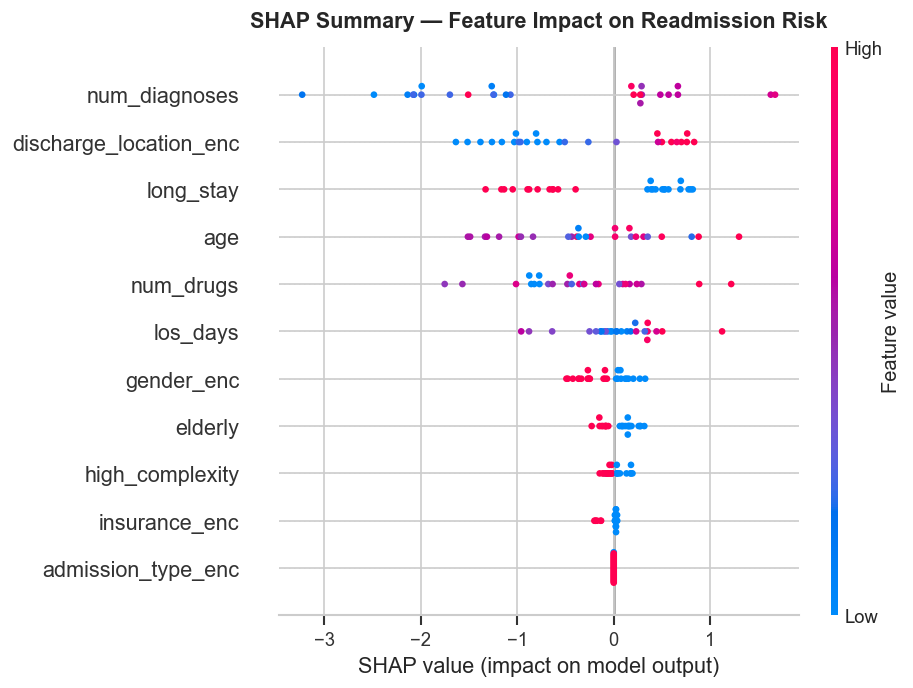

✅ Saved: outputs/plot_09_shap_summary.png


In [19]:
# SHAP Summary Beeswarm Plot
shap.summary_plot(shap_vals, X_test,
                  feature_names=FEATURES, show=False)
plt.title("SHAP Summary — Feature Impact on Readmission Risk",
          fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("outputs/plot_09_shap_summary.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_09_shap_summary.png")


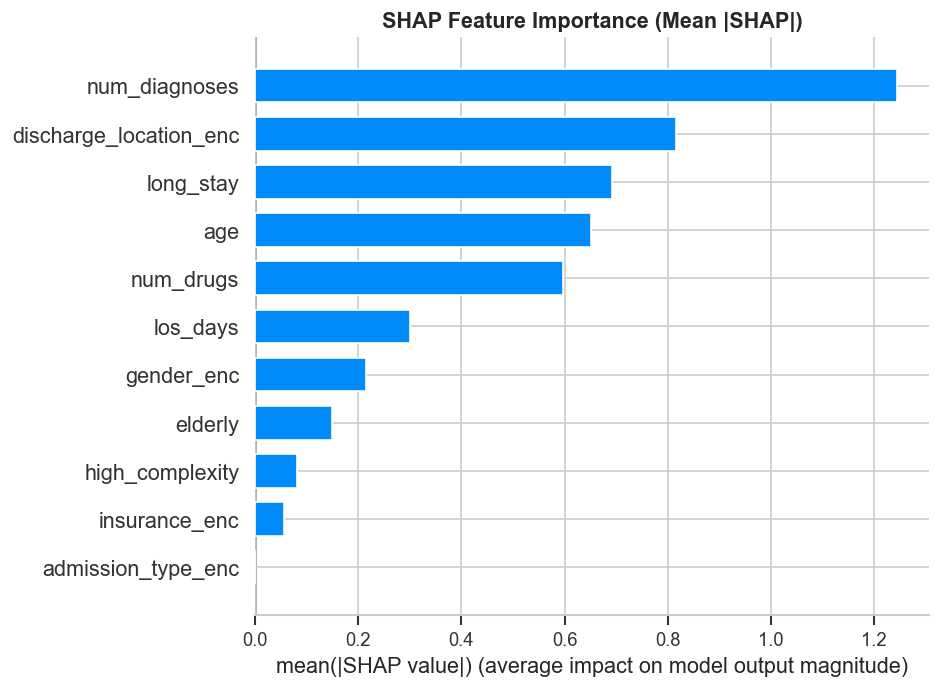

✅ Saved: outputs/plot_10_shap_bar.png


In [20]:
# SHAP Bar Plot (global importance)
shap.summary_plot(shap_vals, X_test,
                  feature_names=FEATURES,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_10_shap_bar.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_10_shap_bar.png")


Patient index  : 11
Predicted risk : 87.6%
Actual outcome : Not Readmitted


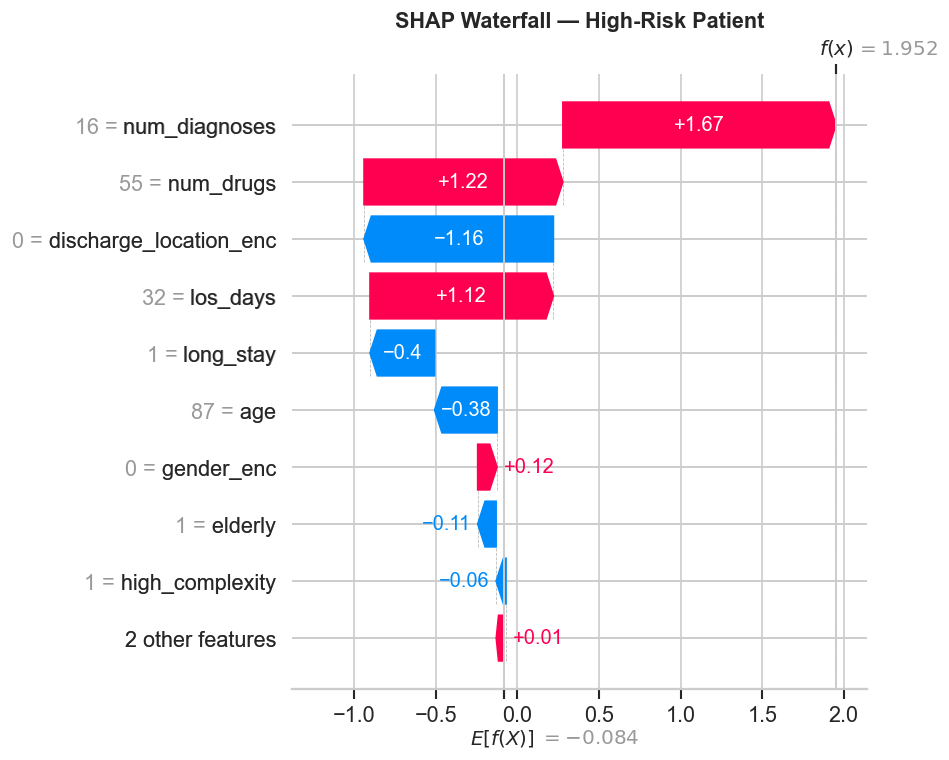

✅ Saved: outputs/plot_11_shap_waterfall.png


In [21]:
# SHAP Waterfall — High-risk patient
high_idx = int(np.argmax(y_prob))
print(f"Patient index  : {high_idx}")
print(f"Predicted risk : {y_prob[high_idx]*100:.1f}%")
print(f"Actual outcome : {'Readmitted' if y_test.iloc[high_idx]==1 else 'Not Readmitted'}")

shap_exp = shap.Explanation(
    values       = shap_vals[high_idx],
    base_values  = explainer.expected_value,
    data         = X_test.iloc[high_idx].values,
    feature_names= FEATURES
)
shap.waterfall_plot(shap_exp, show=False)
plt.title("SHAP Waterfall — High-Risk Patient", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_11_shap_waterfall.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_11_shap_waterfall.png")


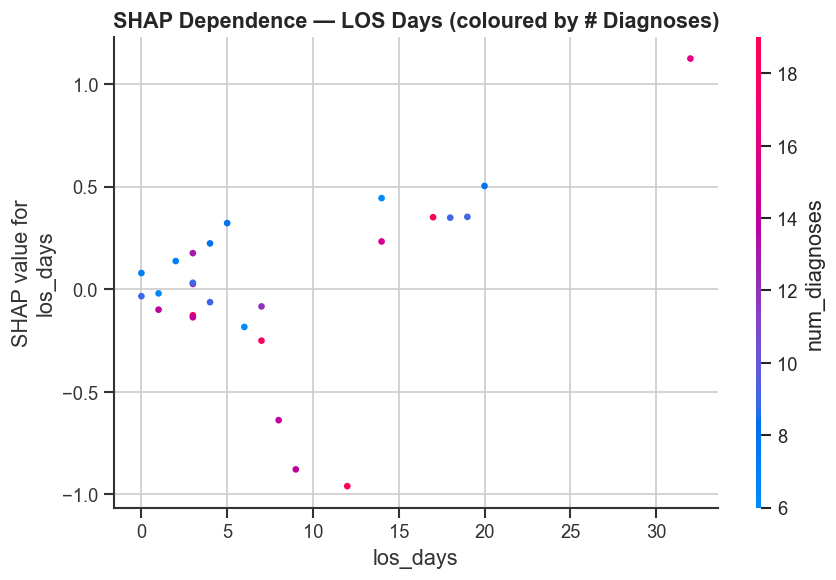

✅ Saved: outputs/plot_12_shap_dependence.png


In [22]:
# SHAP Dependence Plot — LOS vs risk
shap.dependence_plot(
    "los_days", shap_vals, X_test,
    feature_names=FEATURES,
    interaction_index="num_diagnoses",
    show=False
)
plt.title("SHAP Dependence — LOS Days (coloured by # Diagnoses)",
          fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_12_shap_dependence.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_12_shap_dependence.png")


## Cell 13 — Export All Outputs

In [23]:
os.makedirs("outputs", exist_ok=True)

# 1. Risk scores for ALL patients → Power BI
all_prob = model.predict_proba(X)[:, 1]
risk_df  = df_model[["subject_id"]].copy() if "subject_id" in df_model.columns            else pd.DataFrame({"subject_id": range(len(df_model))})
risk_df["risk_score"]   = all_prob.round(4)
risk_df["risk_pct"]     = (all_prob * 100).round(1)
risk_df["target"]       = y.values
risk_df["risk_tier"]    = pd.cut(all_prob,
                            bins=[0, 0.30, 0.60, 1.0],
                            labels=["Low Risk","Medium Risk","High Risk"])
risk_df["prediction"]   = model.predict(X)
risk_df                 = risk_df.sort_values("risk_score", ascending=False)
risk_df.to_csv("outputs/risk_scores.csv", index=False, encoding="utf-8-sig")
print("✅ Saved: outputs/risk_scores.csv")

# 2. Trained model → Streamlit app
joblib.dump(model,    "outputs/readmission_model.pkl")
print("✅ Saved: outputs/readmission_model.pkl")

# 3. Label encoders → Streamlit inference
joblib.dump(le_dict,  "outputs/label_encoders.pkl")
print("✅ Saved: outputs/label_encoders.pkl")

# 4. Feature list → inference consistency
joblib.dump(FEATURES, "outputs/feature_names.pkl")
print("✅ Saved: outputs/feature_names.pkl")

# 5. SHAP values → offline analysis
shap_df = pd.DataFrame(shap_vals, columns=FEATURES)
shap_df.to_csv("outputs/shap_values.csv", index=False)
print("✅ Saved: outputs/shap_values.csv")

# 6. Summary table
print("=== Files in outputs/ ===")
for f in sorted(os.listdir("outputs")):
    sz = os.path.getsize(f"outputs/{f}")
    print(f"  {f:<40} {sz:>8,} bytes")


✅ Saved: outputs/risk_scores.csv
✅ Saved: outputs/readmission_model.pkl
✅ Saved: outputs/label_encoders.pkl
✅ Saved: outputs/feature_names.pkl
✅ Saved: outputs/shap_values.csv
=== Files in outputs/ ===
  feature_names.pkl                             176 bytes
  label_encoders.pkl                          1,424 bytes
  plot_01_class_balance.png                  44,151 bytes
  plot_02_distributions.png                  69,681 bytes
  plot_03_categorical.png                    94,653 bytes
  plot_04_heatmap.png                        40,125 bytes
  plot_05_model_comparison.png               35,858 bytes
  plot_06_confusion_roc.png                  59,988 bytes
  plot_07_precision_recall.png               34,046 bytes
  plot_08_feature_importance.png             48,689 bytes
  plot_09_shap_summary.png                   70,873 bytes
  plot_10_shap_bar.png                       46,987 bytes
  plot_11_shap_waterfall.png                 61,552 bytes
  plot_12_shap_dependence.png               

## Cell 14 — Final Performance Summary

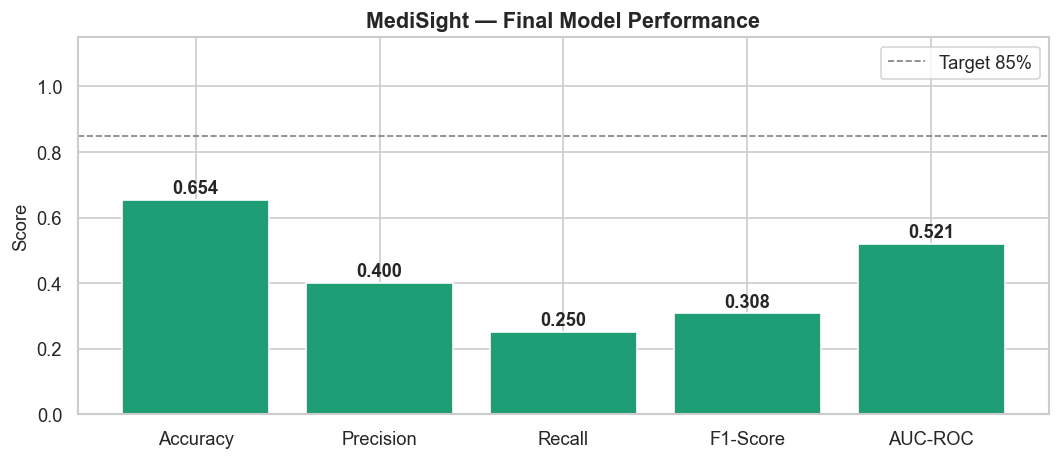

  MEDISIGHT — FINAL RESULTS
  ⚠️  Accuracy      0.6538
  ⚠️  Precision     0.4000
  ⚠️  Recall        0.2500
  ⚠️  F1-Score      0.3077
  ⚠️  AUC-ROC       0.5208

📁 All outputs saved in outputs/ folder:
   risk_scores.csv        → import into Power BI
   readmission_model.pkl  → use in Streamlit app
   label_encoders.pkl     → use in Streamlit app
   feature_names.pkl      → use in Streamlit app
   shap_values.csv        → offline analysis

🎯 Next: Phase 4 → Power BI Dashboard


In [24]:
metrics = {
    "Accuracy"  : accuracy_score(y_test, y_pred),
    "Precision" : precision_score(y_test, y_pred, zero_division=0),
    "Recall"    : recall_score(y_test, y_pred, zero_division=0),
    "F1-Score"  : f1_score(y_test, y_pred, zero_division=0),
    "AUC-ROC"   : roc_auc_score(y_test, y_prob),
}

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
bar_c = ["#D85A30" if v >= 0.85 else "#EF9F27" if v >= 0.75
          else "#1D9E75" for v in metrics.values()]
bars  = ax.bar(metrics.keys(), metrics.values(),
               color=bar_c, edgecolor="white")
ax.set_ylim(0, 1.15)
ax.axhline(0.85, color="gray", linestyle="--", lw=1, label="Target 85%")
ax.set_title("MediSight — Final Model Performance", fontweight="bold")
ax.set_ylabel("Score")
ax.legend()
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/plot_13_final_summary.png", bbox_inches="tight")
plt.show()

# Print summary
print("" + "="*50)
print("  MEDISIGHT — FINAL RESULTS")
print("="*50)
for metric, val in metrics.items():
    flag = "✅" if val >= 0.75 else "⚠️"
    print(f"  {flag}  {metric:<12}  {val:.4f}")
print("="*50)
print()
print("📁 All outputs saved in outputs/ folder:")
print("   risk_scores.csv        → import into Power BI")
print("   readmission_model.pkl  → use in Streamlit app")
print("   label_encoders.pkl     → use in Streamlit app")
print("   feature_names.pkl      → use in Streamlit app")
print("   shap_values.csv        → offline analysis")
print()
print("🎯 Next: Phase 4 → Power BI Dashboard")
